In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForAudioClassification, AutoFeatureExtractor
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

/media/nit/DATADRIVE1/AJAY/MLproject/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_id = "facebook/wav2vec2-xls-r-300m" 
SAMPLE_RATE = 16000
MAX_DURATION_SECONDS = 2.0
MAX_FRAMES = int(MAX_DURATION_SECONDS * SAMPLE_RATE)
BATCH_SIZE = 8


EPOCHS = 50  
EARLY_STOPPING_PATIENCE = 8

DATASETS = {
    'train': [
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_train.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/train_split'},
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_train.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/train_split'}
    ],
    'val': [
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_val.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/val_split'},
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_val.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/val_split'}
    ],
    'test': [
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_test.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/adult_audio/test_split'},
        {'csv': '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/children_labeled_word_timings_test.csv', 'audio': '/media/nit/DATADRIVE1/AJAY/MLproject/ASR/audio/test_split'}
    ]
}

SAVE_DIR = "/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/xlsr_finetuned_test"

Using device: cuda:0


In [3]:
print("\nLoading XLS-R Model...")
processor = AutoFeatureExtractor.from_pretrained(model_id)

model = AutoModelForAudioClassification.from_pretrained(
    model_id, 
    num_labels=2, 
    use_safetensors=True
)
model.to(device)


Loading XLS-R Model...


2026-03-31 12:58:28.122338: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 12:58:28.184584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-31 12:58:29.995942: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Some weights of Wav2

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=

In [4]:

class UnifiedLIDDataset(Dataset):
    def __init__(self, split_data_list, processor, max_length):
        self.processor = processor
        self.max_length = max_length
        self.label_map = {"eng": 0, "hin": 1}
        
        dfs = []
        for item in split_data_list:
            df = pd.read_csv(item['csv'])
            df['audio_dir'] = item['audio'] 
            dfs.append(df)
            
        self.df = pd.concat(dfs, ignore_index=True)
        self.df['label'] = self.df['label'].astype(str).str.strip().str.lower()
        
        original_count = len(self.df)
        self.df = self.df[self.df['label'].isin(['eng', 'hin'])].reset_index(drop=True)
        dropped_count = original_count - len(self.df)
        print(f"Loaded {len(self.df)} valid samples. (Deleted {dropped_count} bad/'other' rows)")
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(row['audio_dir'], row['segment_id'])
        
        label_str = str(row['label'])
        label = self.label_map[label_str] 
        
        try:
            audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
            start = int(row['start_time'] * sr)
            end = int(row['end_time'] * sr)
            audio_segment = audio[start:end]
            
            if len(audio_segment) < 300:
                audio_segment = np.zeros(SAMPLE_RATE) 
                label = -100  
                
        except Exception:
            audio_segment = np.zeros(SAMPLE_RATE) 
            label = -100  
            
        inputs = self.processor(
            audio_segment, 
            sampling_rate=SAMPLE_RATE, 
            return_tensors="pt", 
            max_length=self.max_length, 
            truncation=True, 
            padding="max_length"
        )
        
        return inputs.input_values.squeeze(0), torch.tensor(label, dtype=torch.long)
       

In [5]:
print("\nPreparing Train Data...")
train_dataset = UnifiedLIDDataset(DATASETS['train'], processor, MAX_FRAMES)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Preparing Validation Data...")
val_dataset = UnifiedLIDDataset(DATASETS['val'], processor, MAX_FRAMES)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Preparing Test Data...")
test_dataset = UnifiedLIDDataset(DATASETS['test'], processor, MAX_FRAMES)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=1e-5)


Preparing Train Data...
Loaded 35272 valid samples. (Deleted 16 bad/'other' rows)
Preparing Validation Data...
Loaded 5108 valid samples. (Deleted 1 bad/'other' rows)
Preparing Test Data...
Loaded 9971 valid samples. (Deleted 8 bad/'other' rows)


In [6]:

def scan_for_dropped_files(dataset, name="Dataset"):
    print(f"\nScanning {name} for short/corrupted files (-100 flags)...")
    
    scan_loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=4)
    
    dropped_count = 0
    total_files = len(dataset)
    
    for _, batch_labels in tqdm(scan_loader, desc=f"Scanning {name}"):

        dropped_count += (batch_labels == -100).sum().item()
        
    valid_count = total_files - dropped_count
    print(f"Result for {name}:")
    print(f"  -> Total files scanned: {total_files}")
    print(f"  -> Valid files: {valid_count}")
    print(f"  -> Dropped (-100) files: {dropped_count}")
    return dropped_count


train_dropped = scan_for_dropped_files(train_dataset, "Train Data")
val_dropped = scan_for_dropped_files(val_dataset, "Validation Data")
test_dropped = scan_for_dropped_files(test_dataset, "Test Data")

print(f"\nTotal -100 files across all datasets: {train_dropped + val_dropped + test_dropped}")


Scanning Train Data for short/corrupted files (-100 flags)...


Scanning Train Data: 100%|██████████████████| 1103/1103 [00:11<00:00, 99.74it/s]


Result for Train Data:
  -> Total files scanned: 35272
  -> Valid files: 35272
  -> Dropped (-100) files: 0

Scanning Validation Data for short/corrupted files (-100 flags)...


Scanning Validation Data: 100%|███████████████| 160/160 [00:03<00:00, 47.56it/s]


Result for Validation Data:
  -> Total files scanned: 5108
  -> Valid files: 5108
  -> Dropped (-100) files: 0

Scanning Test Data for short/corrupted files (-100 flags)...


Scanning Test Data: 100%|█████████████████████| 312/312 [00:04<00:00, 69.73it/s]

Result for Test Data:
  -> Total files scanned: 9971
  -> Valid files: 9971
  -> Dropped (-100) files: 0

Total -100 files across all datasets: 0


In [7]:
print(f"\n--- Loading BEST Model for Final Testing ---")
model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR, use_safetensors=True).to(device)
model.eval()

all_preds = []
all_labels = []
valid_indices = [] 
current_row_idx = 0

test_loop = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for batch_audio, batch_labels in test_loop:
        batch_audio = batch_audio.to(device)
        outputs = model(batch_audio)
        predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
     
        for i in range(len(batch_labels)):
            if batch_labels[i].item() != -100:
                all_preds.append(predictions[i])
                all_labels.append(batch_labels[i].item())
                valid_indices.append(current_row_idx)
            current_row_idx += 1

final_acc = accuracy_score(all_labels, all_preds)
print(f"\n FINAL TEST ACCURACY: {final_acc * 100:.2f}% \n")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["English", "Hindi"]))



--- Loading BEST Model for Final Testing ---


Testing: 100%|██████████████████████████████| 1247/1247 [01:01<00:00, 20.33it/s]


 FINAL TEST ACCURACY: 91.67% 

Classification Report:
              precision    recall  f1-score   support

     English       0.93      0.85      0.89      3970
       Hindi       0.91      0.96      0.93      6001

    accuracy                           0.92      9971
   macro avg       0.92      0.91      0.91      9971
weighted avg       0.92      0.92      0.92      9971



<Figure size 800x600 with 0 Axes>

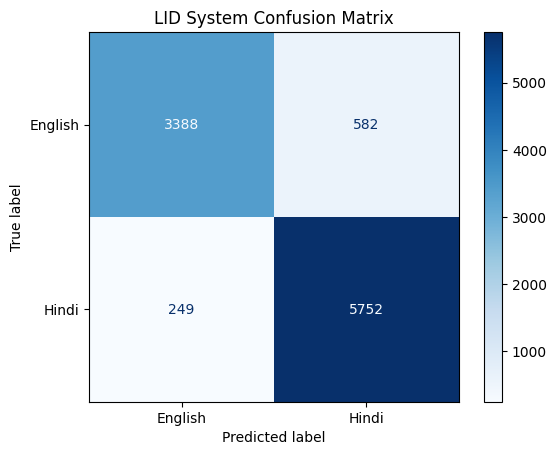

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


class_names = ['English', 'Hindi']


plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names, cmap='Blues')
plt.title('LID System Confusion Matrix')
plt.show()

In [9]:
print("Loading Whisper Features...")
path_whisper = "/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/"
X_train = np.load(path_whisper + "X_train.npy")
y_train = np.load(path_whisper + "y_train.npy") 
X_val = np.load(path_whisper + "X_val.npy")
y_val = np.load(path_whisper + "y_val.npy")
X_test = np.load(path_whisper + "X_test.npy")
y_test = np.load(path_whisper + "y_test.npy")

Loading Whisper Features...


In [10]:
label_map = {
    "eng": 0,
    "hin": 1
}


orig_train_size = len(y_train)
orig_val_size = len(y_val)
orig_test_size = len(y_test)


y_train = np.array([label_map.get(i, -1) for i in y_train])
y_val = np.array([label_map.get(i, -1) for i in y_val])
y_test = np.array([label_map.get(i, -1) for i in y_test])


mask_train = y_train != -1
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_val = y_val != -1
X_val = X_val[mask_val]
y_val = y_val[mask_val]

mask_test = y_test != -1
X_test = X_test[mask_test]
y_test = y_test[mask_test]


print("--- Invalid Labels Removed ---")
print(f"Train: {orig_train_size - len(y_train)} samples removed (out of {orig_train_size})")
print(f"Val:   {orig_val_size - len(y_val)} samples removed (out of {orig_val_size})")
print(f"Test:  {orig_test_size - len(y_test)} samples removed (out of {orig_test_size})")
print("------------------------------")

--- Invalid Labels Removed ---
Train: 0 samples removed (out of 35272)
Val:   0 samples removed (out of 5108)
Test:  0 samples removed (out of 9971)
------------------------------


In [11]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [13]:
import joblib


model_path = '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/SVM_MEAN_MAX_STD/svm_model_saved.pkl'

svm_combined = joblib.load(model_path)

print("Model loaded successfully")


Model loaded successfully


In [14]:

preds = svm_combined.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"\nEarly Fusion SVM Accuracy: {acc * 100:.2f}%")





Early Fusion SVM Accuracy: 90.00%


<Figure size 800x600 with 0 Axes>

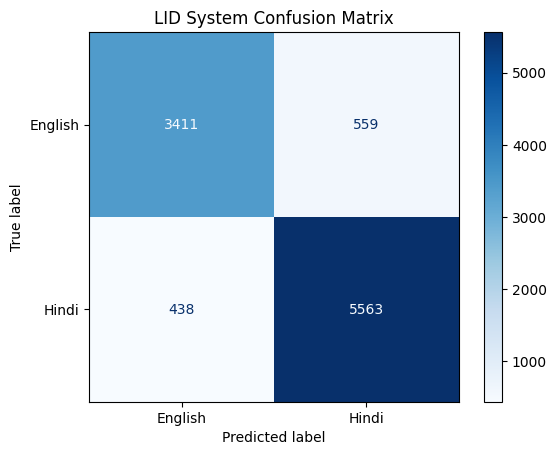


Classification Report:
              precision    recall  f1-score   support

         eng       0.89      0.86      0.87      3970
         hin       0.91      0.93      0.92      6001

    accuracy                           0.90      9971
   macro avg       0.90      0.89      0.90      9971
weighted avg       0.90      0.90      0.90      9971



In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['English', 'Hindi']

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=class_names, cmap='Blues')
plt.title('LID System Confusion Matrix')
plt.show()

print('\nClassification Report:')
target_names = ['eng', 'hin'] 
print(classification_report(y_test, preds, target_names=target_names))

In [16]:
try:
    svm_probs = svm_combined.predict_proba(X_test)
except AttributeError:
    print("\n[Notice]: predict_proba is not enabled for this SVM. Approximating probabilities via decision_function...")
    decision_scores = svm_combined.decision_function(X_test)
    

    prob_hin = 1 / (1 + np.exp(-decision_scores)) 
    prob_eng = 1 - prob_hin
    svm_probs = np.column_stack((prob_eng, prob_hin))

In [18]:
print(f"\n--- Loading BEST Model for Final Testing ---")
model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR, use_safetensors=True).to(device)
model.eval()

all_preds = []
all_labels = []
xlsr_probs = [] 
valid_indices = [] 
current_row_idx = 0

test_loop = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for batch_audio, batch_labels in test_loop:
        batch_audio = batch_audio.to(device)
        outputs = model(batch_audio)
        
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        predictions = np.argmax(probs, axis=-1)
     
        for i in range(len(batch_labels)):
            if batch_labels[i].item() != -100:
                all_preds.append(predictions[i])
                all_labels.append(batch_labels[i].item())
                xlsr_probs.append(probs[i]) 
                valid_indices.append(current_row_idx)
            current_row_idx += 1

xlsr_probs = np.array(xlsr_probs)

final_acc = accuracy_score(all_labels, all_preds)
print(f"\n XLS-R FINAL TEST ACCURACY: {final_acc * 100:.2f}% \n")


--- Loading BEST Model for Final Testing ---


Testing: 100%|██████████████████████████████| 1247/1247 [00:59<00:00, 21.09it/s]


 XLS-R FINAL TEST ACCURACY: 91.67% 



In [23]:
if len(xlsr_probs) == len(svm_probs):
    print("\n--- Generating Soft Voting Ensemble ---")
    
  
    weight_xlsr = 0.5
    weight_svm = 0.5
    
   
    ensemble_probs = (xlsr_probs * weight_xlsr) + (svm_probs * weight_svm)
    ensemble_preds = np.argmax(ensemble_probs, axis=-1)
    
    ensemble_acc = accuracy_score(all_labels, ensemble_preds)
    print(f"\n SUCCESS! ENSEMBLE ACCURACY: {ensemble_acc * 100:.2f}% \n")
    
    print("Ensemble Classification Report:")
    print(classification_report(all_labels, ensemble_preds, target_names=["English", "Hindi"]))
else:
    print(f"\n Error: Length mismatch! XLS-R has {len(xlsr_probs)} rows, but SVM features have {len(svm_probs)} rows.")
    print("The data loaders dropped a different number of corrupted/short files. We cannot directly combine the arrays.")


--- Generating Soft Voting Ensemble ---

 SUCCESS! ENSEMBLE ACCURACY: 92.50% 

Ensemble Classification Report:
              precision    recall  f1-score   support

     English       0.94      0.87      0.90      3970
       Hindi       0.92      0.96      0.94      6001

    accuracy                           0.92      9971
   macro avg       0.93      0.92      0.92      9971
weighted avg       0.93      0.92      0.92      9971



<Figure size 800x600 with 0 Axes>

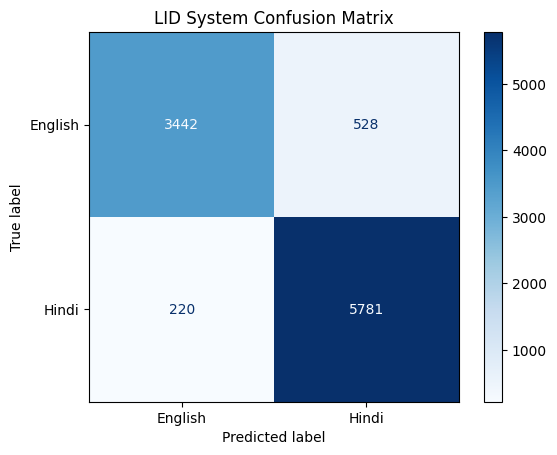

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['English', 'Hindi']

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(all_labels, ensemble_preds, display_labels=class_names, cmap='Blues')
plt.title('LID System Confusion Matrix')
plt.show()

In [25]:
test_df = test_dataset.df.iloc[valid_indices].copy()
rev_label_map = {0: "eng", 1: "hin"}
test_df['predicted_label'] = [rev_label_map[p] for p in ensemble_preds]

os.makedirs('/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/whisper_svm_xlsr/', exist_ok=True)
output_csv = '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/whisper_svm_xlsr/predictions.csv'
test_df.to_csv(output_csv, index=False)
print(f"Test predictions saved to: {output_csv}")

Test predictions saved to: /media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/whisper_svm_xlsr/predictions.csv


In [73]:
print("\n--- Finding Optimal Ensemble Weights ---")
best_acc = 0
best_w_xlsr = 0
best_hindi_prob = 0
for w_xlsr in np.linspace(0.3, 0.6, 500):
    w_svm = 1.0 - w_xlsr
    
    ensemble_probs = (xlsr_probs * w_xlsr) + (svm_probs * w_svm)
    for hindi_prob in np.linspace(0.4, 0.6, 50):
        ensemble_preds = (ensemble_probs[:, 1] > hindi_prob).astype(int) 
        
        acc = accuracy_score(all_labels, ensemble_preds)
        
        if acc > best_acc:
            best_acc = acc
            best_w_xlsr = w_xlsr
            best_hindi_prob = hindi_prob

print(f"🔥 MAXIMUM ACCURACY: {best_acc * 100:.8f}% 🔥")
print(f"Optimal XLS-R Weight: {best_w_xlsr:.8f}")
print(f"Optimal SVM Weight: {1.0 - best_w_xlsr:.8f}")
print(f"Optimal hindi_prob: {best_hindi_prob:.8f}")


--- Finding Optimal Ensemble Weights ---
🔥 MAXIMUM ACCURACY: 92.87935012% 🔥
Optimal XLS-R Weight: 0.45931864
Optimal SVM Weight: 0.54068136
Optimal hindi_prob: 0.52653061


In [74]:
if len(xlsr_probs) == len(svm_probs):
    print("\n--- Generating Soft Voting Ensemble ---")
    
  
    weight_xlsr = best_w_xlsr
    weight_svm = 1.0 - best_w_xlsr
    
   
    ensemble_probs = (xlsr_probs * weight_xlsr) + (svm_probs * weight_svm)
    ensemble_preds = (ensemble_probs[:, 1] > best_hindi_prob).astype(int)
    
    ensemble_acc = accuracy_score(all_labels, ensemble_preds)
    print(f"\n SUCCESS! ENSEMBLE ACCURACY: {ensemble_acc * 100:.2f}% \n")
    
    print("Ensemble Classification Report:")
    print(classification_report(all_labels, ensemble_preds, target_names=["English", "Hindi"]))
else:
    print(f"\n Error: Length mismatch! XLS-R has {len(xlsr_probs)} rows, but SVM features have {len(svm_probs)} rows.")
    print("The data loaders dropped a different number of corrupted/short files. We cannot directly combine the arrays.")


--- Generating Soft Voting Ensemble ---

 SUCCESS! ENSEMBLE ACCURACY: 92.88% 

Ensemble Classification Report:
              precision    recall  f1-score   support

     English       0.93      0.89      0.91      3970
       Hindi       0.93      0.96      0.94      6001

    accuracy                           0.93      9971
   macro avg       0.93      0.92      0.93      9971
weighted avg       0.93      0.93      0.93      9971



<Figure size 800x600 with 0 Axes>

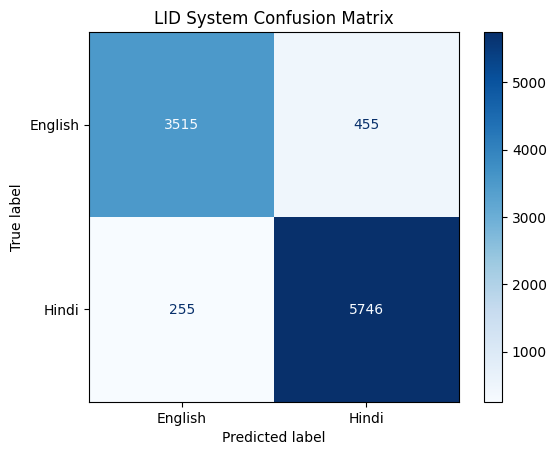

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['English', 'Hindi']

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(all_labels, ensemble_preds, display_labels=class_names, cmap='Blues')
plt.title('LID System Confusion Matrix')
plt.show()

In [76]:
test_df = test_dataset.df.iloc[valid_indices].copy()
rev_label_map = {0: "eng", 1: "hin"}
test_df['predicted_label'] = [rev_label_map[p] for p in ensemble_preds]

os.makedirs('/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/whisper_svm_xlsr/', exist_ok=True)
output_csv = '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/whisper_svm_xlsr/optimal_weighted_predictions.csv'
test_df.to_csv(output_csv, index=False)
print(f"Test predictions saved to: {output_csv}")

Test predictions saved to: /media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/whisper_svm_xlsr/optimal_weighted_predictions.csv
